# Análise Exploratória dos Dados (EDA)

## Objetivo
Esta etapa tem como objetivo compreender a estrutura do dataset, identificar problemas de qualidade dos dados, analisar a distribuição das variáveis e gerar insights que orientem a preparação dos dados e a modelagem preditiva.

## Problema
O projeto busca prever a variável `Qualidade_Ambiental` com base em medições ambientais, como temperatura, umidade e concentração de gases.


## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set(style="whitegrid", palette="deep")

## Carregamento dos dados

In [2]:
df = pd.read_csv("../data/dataset_ambiental.csv")
df.head()

,Temperatura,Umidade,CO2,CO,Pressao_Atm,NO2,SO2,O3,Qualidade_Ambiental
0,21.236204,46.154857,1540.997129,31.907228,979.8912041204417,85.487475,37.336205,14.692721,Moderada
1,38.521429,43.303847,613.670393,22.964623,959.4817775162059,51.979119,44.173992,101.135508,Moderada
2,31.959818,32.330774,19998.316609,48.224926,962.6359224972216,23.569233,23.695814,37.423834,Moderada
3,27.959755,62.508667,1427.577083,10.948923,968.0671128180921,74.980970,15.169758,41.233110,Moderada
4,14.680559,53.363691,1119.551886,29.392821,970.3653334364949,44.774423,16.623482,34.886981,Moderada


## Visão geral do dataset

In [3]:
print("Dimensões do dataset:", df.shape)
print("\nColunas:")
print(df.columns.tolist())

print("\nInformações gerais:")
df.info()

Dimensões do dataset: (10000, 9)

Colunas:
['Temperatura', 'Umidade', 'CO2', 'CO', 'Pressao_Atm', 'NO2', 'SO2', 'O3', 'Qualidade_Ambiental']

Informações gerais:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Temperatura          9900 non-null   float64
 1   Umidade              9800 non-null   float64
 2   CO2                  10000 non-null  float64
 3   CO                   10000 non-null  float64
 4   Pressao_Atm          10000 non-null  object 
 5   NO2                  10000 non-null  float64
 6   SO2                  10000 non-null  float64
 7   O3                   10000 non-null  float64
 8   Qualidade_Ambiental  10000 non-null  object 
dtypes: float64(7), object(2)
memory usage: 703.3+ KB


## Valores ausentes

In [4]:
df.isnull().sum()

Temperatura            100
Umidade                200
CO2                      0
CO                       0
Pressao_Atm              0
NO2                      0
SO2                      0
O3                       0
Qualidade_Ambiental      0
dtype: int64

In [5]:
(df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

Umidade                2.0
Temperatura            1.0
CO2                    0.0
CO                     0.0
Pressao_Atm            0.0
NO2                    0.0
SO2                    0.0
O3                     0.0
Qualidade_Ambiental    0.0
dtype: float64

 ## Inspeção da variável

In [6]:
df["Pressao_Atm"].head(10)

0     979.8912041204417
1     959.4817775162059
2     962.6359224972216
3     968.0671128180921
4     970.3653334364949
5     974.2261809210544
6     975.5460028963495
7     995.5716345487535
8    1000.9573190826042
9     980.8879208126356
Name: Pressao_Atm, dtype: object

In [7]:
df["Pressao_Atm"].value_counts().head(10)

Pressao_Atm
erro_sensor           100
979.8912041204417       1
1018.1657452926172      1
1009.0184320394969      1
1030.5392342870143      1
967.2117534406517       1
992.2822960826192       1
1024.048976847986       1
1003.2636571765186      1
979.2869195875815       1
Name: count, dtype: int64

## Distribuição da variável alvo

In [8]:
df["Qualidade_Ambiental"].value_counts()

Qualidade_Ambiental
Moderada      5912
Ruim          2569
Boa           1453
Muito Ruim      55
Excelente       11
Name: count, dtype: int64

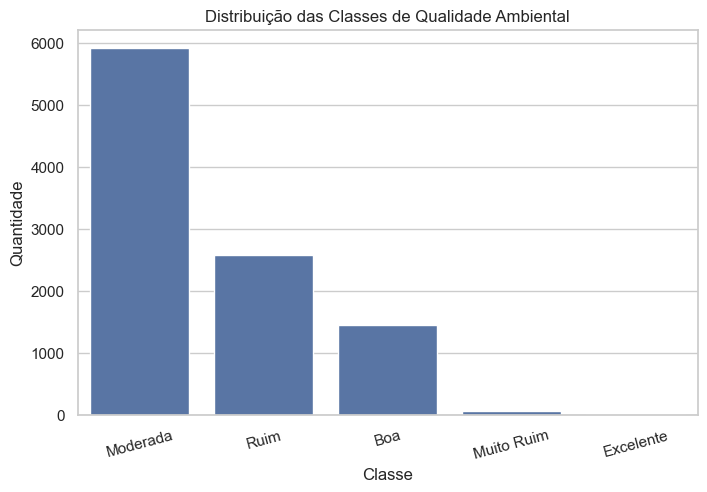

In [9]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Qualidade_Ambiental", order=df["Qualidade_Ambiental"].value_counts().index)
plt.title("Distribuição das Classes de Qualidade Ambiental")
plt.xlabel("Classe")
plt.ylabel("Quantidade")
plt.xticks(rotation=15)
plt.show()

## Estatísticas descritivas

In [10]:
df.describe(include="all")

,Temperatura,Umidade,CO2,CO,Pressao_Atm,NO2,SO2,O3,Qualidade_Ambiental
count,9900.000000,9800.000000,10000.000000,10000.000000,10000,10000.000000,10000.000000,10000.000000,10000
unique,NaN,NaN,NaN,NaN,9901,NaN,NaN,NaN,5
top,NaN,NaN,NaN,NaN,erro_sensor,NaN,NaN,NaN,Moderada
freq,NaN,NaN,NaN,NaN,100,NaN,NaN,NaN,5912
mean,24.818747,55.308556,1526.799620,24.935669,NaN,52.798736,25.587618,64.914693,NaN
std,8.627029,20.243330,2682.748551,14.449730,NaN,27.392422,14.095238,31.456487,NaN
min,10.000349,20.011042,300.081811,0.000277,NaN,5.000801,1.013236,10.014301,NaN
25%,17.386090,37.780522,739.875009,12.342862,NaN,29.410865,13.440352,37.719825,NaN
50%,24.775593,55.380697,1168.936432,25.001512,NaN,53.078587,25.706263,64.915458,NaN
75%,32.175026,72.899768,1592.929532,37.355813,NaN,76.577367,37.870990,92.260420,NaN


## Corrigindo temporariamente Pressao_Atm para análise

In [11]:
df_eda = df.copy()
df_eda["Pressao_Atm"] = pd.to_numeric(df_eda["Pressao_Atm"], errors="coerce")
df_eda.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Temperatura          9900 non-null   float64
 1   Umidade              9800 non-null   float64
 2   CO2                  10000 non-null  float64
 3   CO                   10000 non-null  float64
 4   Pressao_Atm          9900 non-null   float64
 5   NO2                  10000 non-null  float64
 6   SO2                  10000 non-null  float64
 7   O3                   10000 non-null  float64
 8   Qualidade_Ambiental  10000 non-null  object 
dtypes: float64(8), object(1)
memory usage: 703.3+ KB


## Estatísticas após ajuste da pressão

In [12]:
df_eda.describe()

,Temperatura,Umidade,CO2,CO,Pressao_Atm,NO2,SO2,O3
count,9900.000000,9800.000000,10000.000000,10000.000000,9900.000000,10000.000000,10000.000000,10000.000000
mean,24.818747,55.308556,1526.799620,24.935669,999.629957,52.798736,25.587618,64.914693
std,8.627029,20.243330,2682.748551,14.449730,28.931773,27.392422,14.095238,31.456487
min,10.000349,20.011042,300.081811,0.000277,950.001674,5.000801,1.013236,10.014301
25%,17.386090,37.780522,739.875009,12.342862,974.364660,29.410865,13.440352,37.719825
50%,24.775593,55.380697,1168.936432,25.001512,999.277490,53.078587,25.706263,64.915458
75%,32.175026,72.899768,1592.929532,37.355813,1025.002687,76.577367,37.870990,92.260420
max,39.991530,89.994738,19998.316609,49.989469,1049.997215,99.994271,49.984804,119.986261


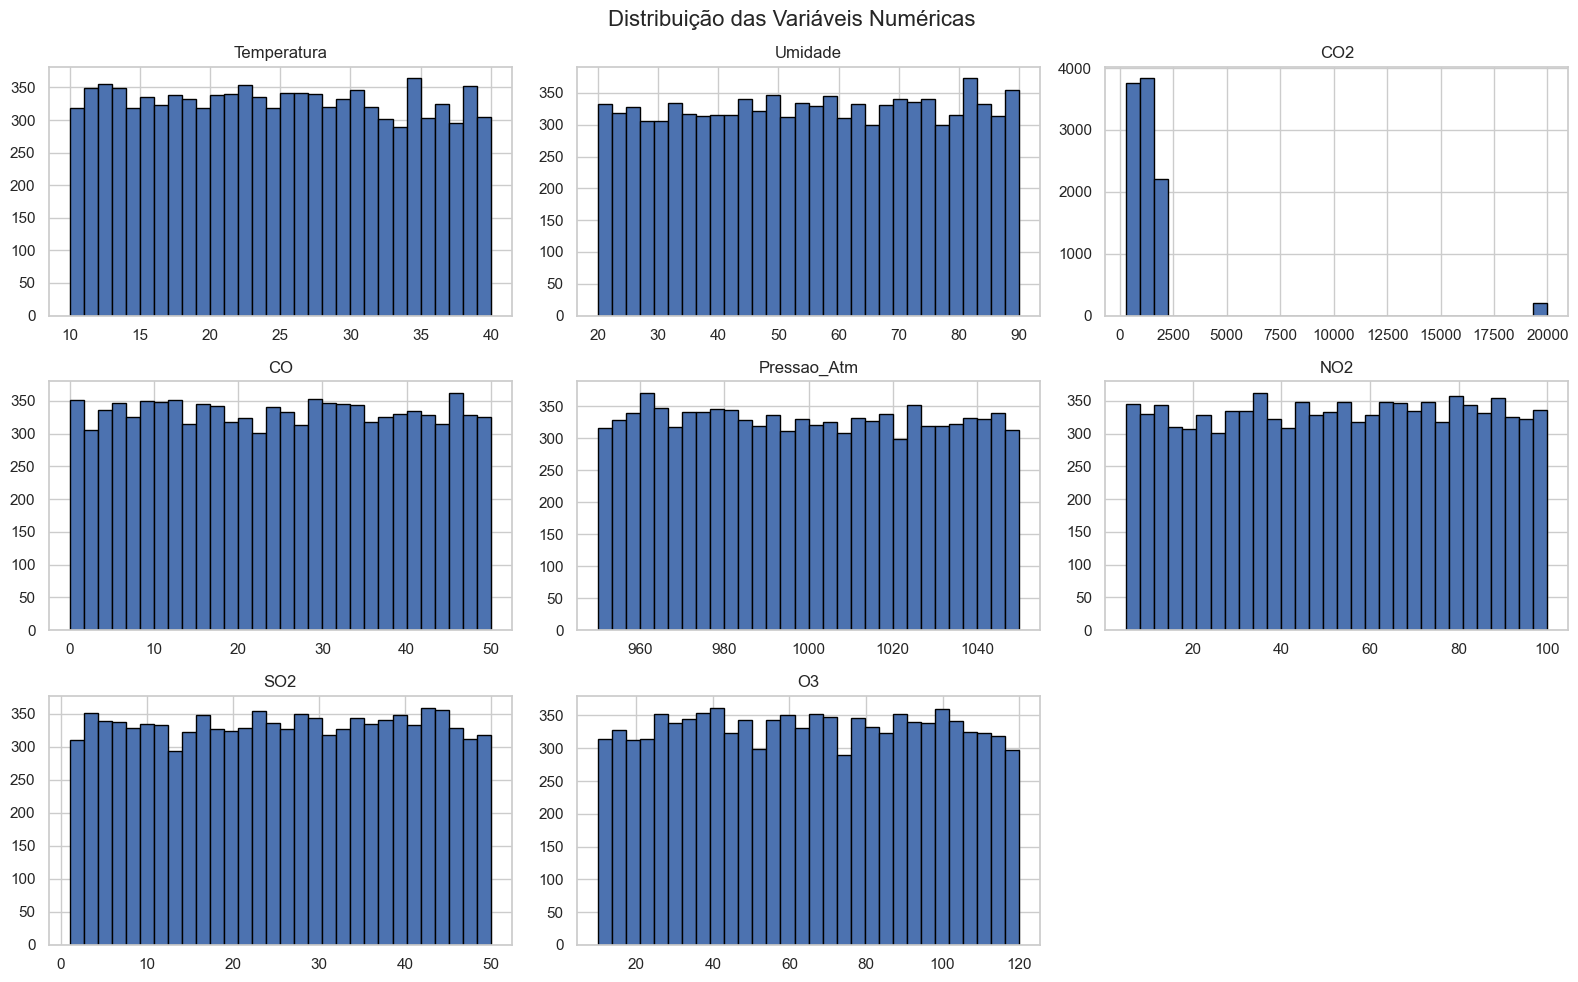

In [13]:
df_eda.hist(figsize=(16, 10), bins=30, edgecolor="black")
plt.suptitle("Distribuição das Variáveis Numéricas", fontsize=16)
plt.tight_layout()
plt.show()

 ## Boxplots para investigar outliers

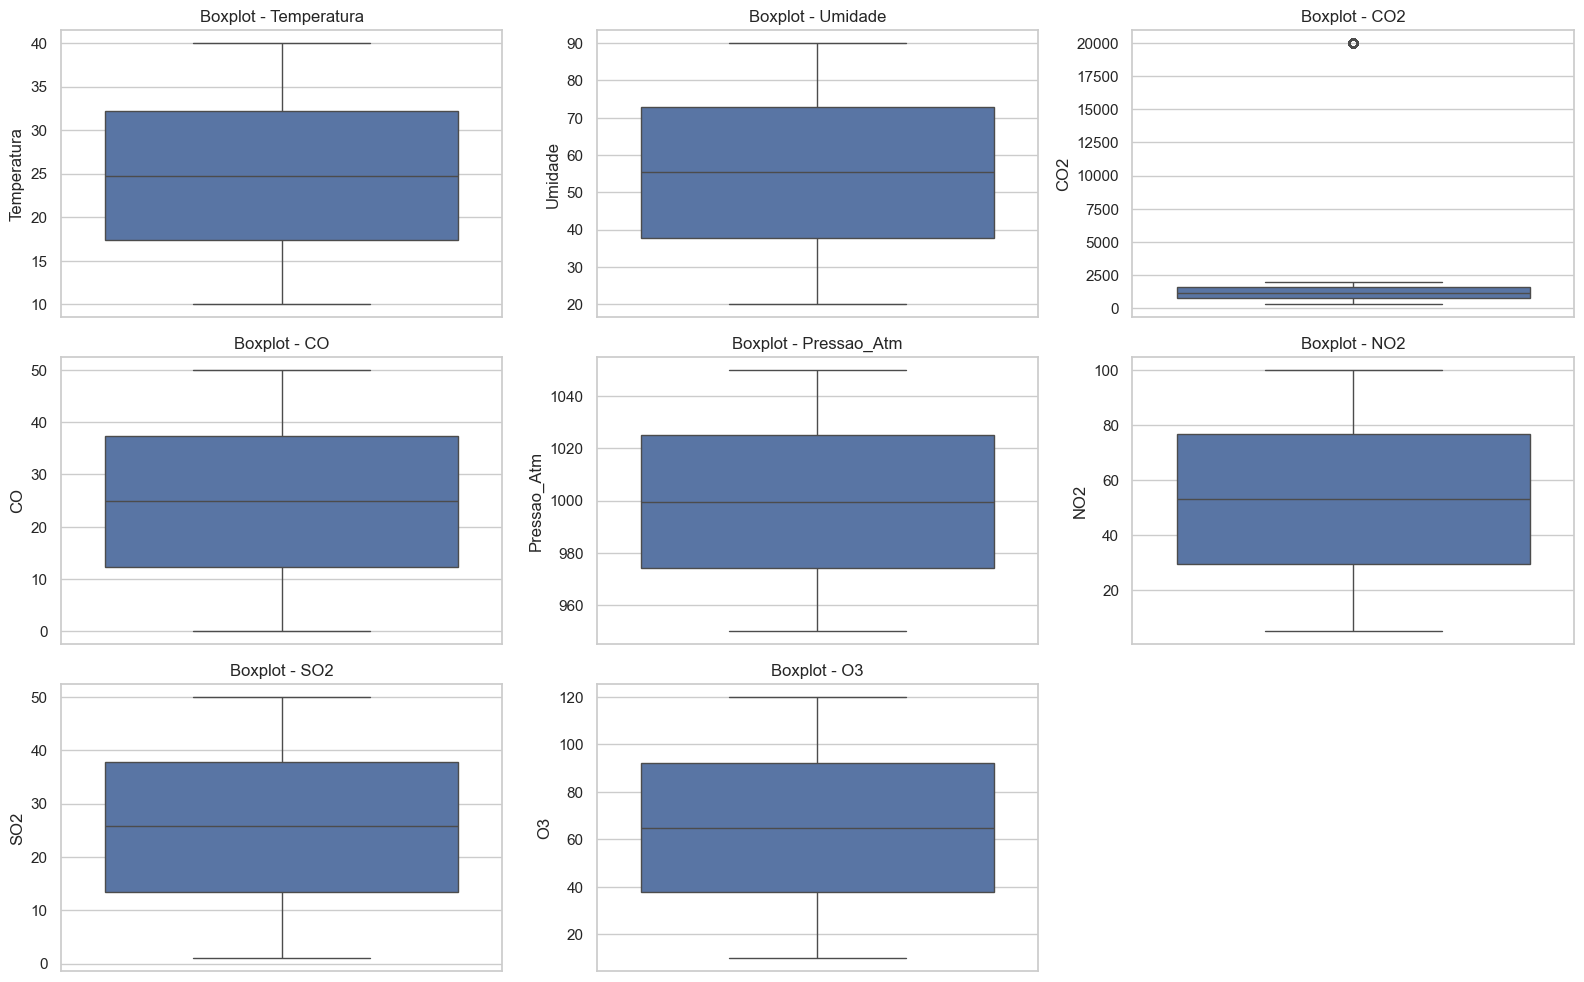

In [14]:
colunas_numericas = df_eda.select_dtypes(include=["float64", "int64"]).columns

plt.figure(figsize=(16, 10))
for i, col in enumerate(colunas_numericas, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df_eda[col])
    plt.title(f"Boxplot - {col}")
plt.tight_layout()
plt.show()

## Mapa de correlação

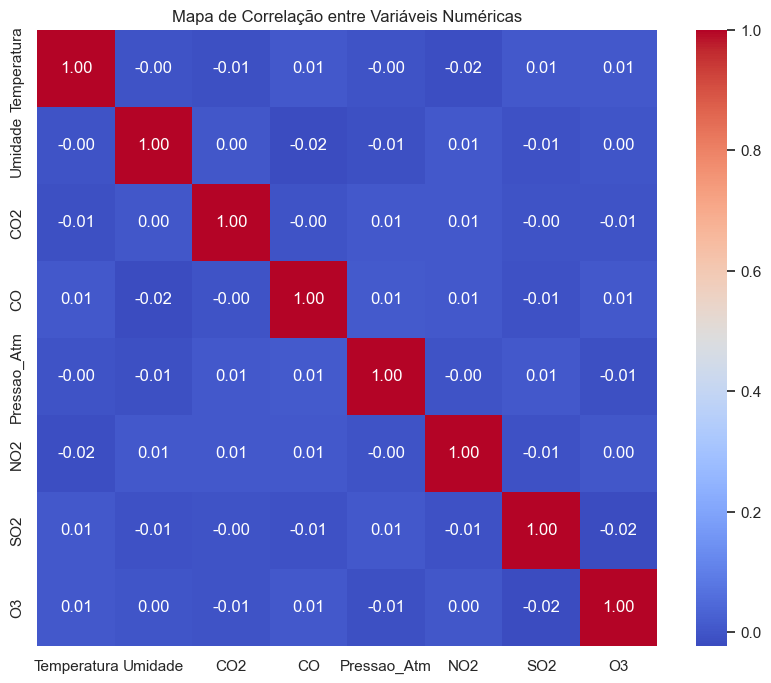

In [15]:
plt.figure(figsize=(10, 8))
corr = df_eda.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Mapa de Correlação entre Variáveis Numéricas")
plt.show()

## Análise por classe

In [16]:
df_eda.groupby("Qualidade_Ambiental").mean(numeric_only=True)

,Temperatura,Umidade,CO2,CO,Pressao_Atm,NO2,SO2,O3
Qualidade_Ambiental,,,,,,,,
Boa,24.536072,55.761173,1078.999788,16.474393,1001.760459,37.132376,17.838105,38.575024
Excelente,26.306079,49.391430,458.171920,7.980706,1011.734073,18.660173,6.880791,18.677598
Moderada,24.949624,55.629344,1515.349017,24.096267,1000.135269,51.423971,24.967458,61.160562
Muito Ruim,23.727635,56.609492,2106.845544,40.373943,992.960855,81.596880,40.789349,108.622460
Ruim,24.693250,54.316668,1798.579109,31.395062,997.355881,64.352827,31.152471,87.713695


## Principais Insights da EDA

- O dataset possui 10.000 registros e 9 variáveis.
- A variável alvo é `Qualidade_Ambiental`, caracterizando um problema de classificação multiclasse.
- Há valores ausentes em `Temperatura` e `Umidade`.
- A coluna `Pressao_Atm` apresenta registros inválidos, como `erro_sensor`, exigindo conversão e tratamento.
- As classes estão desbalanceadas, com predominância de `Moderada`.
- Há indícios de outliers, especialmente em `CO2`.
- Será necessário aplicar preparação dos dados antes do treinamento dos modelos.